# 06 — Hyperparameter Tuning (Optuna)

**Same split as NB05** (train < 2025-07-01, test ≥ 2025-07-01) for fair comparison.

**Improvements over default models:**
- Optuna TPE sampler with MedianPruner (kills bad trials early)
- Early stopping finds optimal tree count per trial (not a tuned hyperparameter)
- 100 trials per model — more exploration in same wall time thanks to pruning
- Weighted ensemble (CatBoost-heavy) based on NB05 finding that CatBoost dominates accuracy
- Confidence tier system based on NB05 agreement analysis

**Two phases:**
1. Tune & evaluate on same test set as NB05 → measure pure hyperparameter improvement
2. Retrain best params on ALL data → production models for future predictions

In [1]:
import pandas as pd
import numpy as np
import json, os, warnings, time
from pathlib import Path

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from lightgbm import early_stopping as lgb_early_stopping
from lightgbm import log_evaluation as lgb_log_eval

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score,
                             brier_score_loss, classification_report,
                             confusion_matrix)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Auto-detect data path
DATA = Path('./data') if Path('./data/model_data.csv').exists() else Path('../data')
MODEL_DIR = Path('../models') if not Path('./models').exists() else Path('./models')
MODEL_DIR.mkdir(exist_ok=True)

print(f"Data path:  {DATA.resolve()}")
print(f"Model path: {MODEL_DIR.resolve()}")

df = pd.read_csv(DATA / 'model_data.csv', parse_dates=['event_date'])
df = df.sort_values('event_date').reset_index(drop=True)

print(f"Loaded: {df.shape[0]:,} fights × {df.shape[1]} columns")
print(f"Date range: {df['event_date'].min().date()} → {df['event_date'].max().date()}")

# Load NB05 baselines
nb05_results = json.load(open(DATA / 'nb05_results.json'))
print(f"\nNB05 baselines loaded:")
for name, metrics in nb05_results.items():
    print(f"  {name:<12s} acc={metrics['acc']:.3f}  auc={metrics['auc']:.3f}  ll={metrics['ll']:.3f}")

Data path:  /workspaces/UFCML/notebooks/data
Model path: /workspaces/UFCML/models
Loaded: 5,485 fights × 322 columns
Date range: 2015-01-03 → 2026-04-11

NB05 baselines loaded:
  XGBoost      acc=0.768  auc=0.864  ll=0.458
  LightGBM     acc=0.781  auc=0.868  ll=0.452
  CatBoost     acc=0.786  auc=0.872  ll=0.457
  Ensemble     acc=0.773  auc=0.871  ll=0.448


## Features & Split — Identical to NB05

Same feature set, same split date. The only thing changing is hyperparameters.

In [2]:
target = 'f1_win'

drop_cols = [
    'event_name', 'event_date', 'fight_url', 'fighter_1', 'fighter_2',
    'winner', 'weight_class', 'round', 'time', 'method_clean', 'finish_type',
    'f1_win', 'stance_matchup', 'f1_stance', 'f2_stance'
]

feature_cols = sorted([c for c in df.columns if c not in drop_cols])
print(f"Features: {len(feature_cols)}")

# ── Identical split ──
SPLIT_DATE = '2025-07-01'

train_mask = df['event_date'] < SPLIT_DATE
test_mask  = df['event_date'] >= SPLIT_DATE

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, target]
X_test  = df.loc[test_mask, feature_cols]
y_test  = df.loc[test_mask, target]

baseline_acc = y_test.mean()
baseline_ll  = log_loss(y_test, np.full(len(y_test), y_train.mean()))

last_train = df.loc[train_mask, 'event_date'].max()
first_test = df.loc[test_mask, 'event_date'].min()

print(f"\nSplit: {SPLIT_DATE}")
print(f"  Train: {len(X_train):,} fights ({df.loc[train_mask, 'event_date'].min().date()} → {last_train.date()})")
print(f"  Test:  {len(X_test):,} fights ({first_test.date()} → {df.loc[test_mask, 'event_date'].max().date()})")
print(f"  Baseline (always red): {baseline_acc:.3f}")
print(f"  Baseline log loss:     {baseline_ll:.3f}")

Features: 310

Split: 2025-07-01
  Train: 5,093 fights (2015-01-03 → 2025-06-28)
  Test:  392 fights (2025-07-12 → 2026-04-11)
  Baseline (always red): 0.554
  Baseline log loss:     0.688


## Cross-Validation Setup

In [3]:
N_SPLITS = 5
N_TRIALS = 100
EARLY_STOP_ROUNDS = 50

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_indices = list(tscv.split(X_train))

print(f"CV: {N_SPLITS}-fold TimeSeriesSplit")
print(f"Trials: {N_TRIALS} per model")
print(f"Early stopping: {EARLY_STOP_ROUNDS} rounds")
print(f"Pruner: MedianPruner (startup=10, warmup=2)")
print()

for i, (tr_idx, val_idx) in enumerate(cv_indices):
    val_dates = df.loc[train_mask].iloc[val_idx]['event_date']
    print(f"  Fold {i+1}: train {len(tr_idx):,} → val {len(val_idx):,}  "
          f"({val_dates.min().date()} → {val_dates.max().date()})")

CV: 5-fold TimeSeriesSplit
Trials: 100 per model
Early stopping: 50 rounds
Pruner: MedianPruner (startup=10, warmup=2)

  Fold 1: train 853 → val 848  (2016-11-19 → 2018-09-08)
  Fold 2: train 1,701 → val 848  (2018-09-08 → 2020-07-11)
  Fold 3: train 2,549 → val 848  (2020-07-11 → 2022-03-12)
  Fold 4: train 3,397 → val 848  (2022-03-12 → 2023-10-21)
  Fold 5: train 4,245 → val 848  (2023-10-21 → 2025-06-28)


## Optuna Objective Factory

Shared logic for all three models:
- `n_estimators` / `iterations` fixed at 3000 — early stopping finds the right count
- Per-fold metrics reported to Optuna pruner
- Stores CV accuracy, log loss, and avg tree count as user attributes

In [4]:
EARLY_STOP_ROUNDS = 20
STORAGE = f"sqlite:///{str(DATA / 'optuna_studies.db')}"

from lightgbm import early_stopping as lgb_early_stopping, log_evaluation as lgb_log_eval

def make_objective(model_type):
    def objective(trial):
        if model_type == 'xgb':
            params = {
                'max_depth':        trial.suggest_int('max_depth', 3, 9),
                'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
                'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
                'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
            }
            fixed = {
                'n_estimators': 3000,
                'early_stopping_rounds': EARLY_STOP_ROUNDS,
                'eval_metric': 'logloss',
                'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
            }
        elif model_type == 'lgb':
            params = {
                'max_depth':        trial.suggest_int('max_depth', 3, 12),
                'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
                'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'num_leaves':       trial.suggest_int('num_leaves', 15, 127),
                'min_split_gain':   trial.suggest_float('min_split_gain', 0.0, 2.0),
            }
            fixed = {
                'n_estimators': 3000,
                'metric': 'binary_logloss',
                'random_state': 42, 'n_jobs': -1, 'verbose': -1,
            }
        elif model_type == 'cat':
            params = {
                'depth':              trial.suggest_int('depth', 3, 9),
                'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
                'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
                'min_data_in_leaf':   trial.suggest_int('min_data_in_leaf', 1, 50),
                'random_strength':    trial.suggest_float('random_strength', 0.0, 5.0),
                'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
                'border_count':       trial.suggest_int('border_count', 32, 255),
                'auto_class_weights': trial.suggest_categorical('auto_class_weights', [None, 'Balanced']),
            }
            fixed = {
                'iterations': 3000,
                'eval_metric': 'Logloss',
                'random_seed': 42, 'verbose': 0,
            }

        fold_lls = []
        fold_accs = []
        fold_iters = []

        for fold_idx, (tr_idx, val_idx) in enumerate(cv_indices):
            X_tr  = X_train.iloc[tr_idx]
            y_tr  = y_train.iloc[tr_idx]
            X_val = X_train.iloc[val_idx]
            y_val = y_train.iloc[val_idx]

            if model_type == 'xgb':
                model = XGBClassifier(**params, **fixed)
                model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
                best_iter = model.best_iteration if hasattr(model, 'best_iteration') and model.best_iteration else 3000
            elif model_type == 'lgb':
                model = LGBMClassifier(**params, **fixed)
                model.fit(X_tr, y_tr,
                         eval_set=[(X_val, y_val)],
                         callbacks=[lgb_early_stopping(EARLY_STOP_ROUNDS), lgb_log_eval(-1)])
                best_iter = model.best_iteration_ if hasattr(model, 'best_iteration_') and model.best_iteration_ and model.best_iteration_ > 0 else 3000
            elif model_type == 'cat':
                model = CatBoostClassifier(**params, **fixed)
                model.fit(X_tr, y_tr,
                         eval_set=(X_val, y_val),
                         early_stopping_rounds=EARLY_STOP_ROUNDS, verbose=0)
                best_iter = model.best_iteration_ if hasattr(model, 'best_iteration_') and model.best_iteration_ else 3000

            y_prob = model.predict_proba(X_val)[:, 1]
            fold_lls.append(log_loss(y_val, y_prob))
            fold_accs.append(accuracy_score(y_val, (y_prob >= 0.5).astype(int)))
            fold_iters.append(best_iter)

            trial.report(float(np.mean(fold_lls)), fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()

        mean_ll  = float(np.mean(fold_lls))
        mean_acc = float(np.mean(fold_accs))
        mean_iter = float(np.mean(fold_iters))

        trial.set_user_attr('cv_accuracy', mean_acc)
        trial.set_user_attr('cv_logloss', mean_ll)
        trial.set_user_attr('avg_best_iteration', mean_iter)
        trial.set_user_attr('fold_accs', [float(a) for a in fold_accs])
        trial.set_user_attr('fold_lls', [float(l) for l in fold_lls])

        return mean_ll

    return objective

print(f"Objective factory ready")
print(f"Storage: {STORAGE}")
print(f"Early stopping: {EARLY_STOP_ROUNDS} rounds")

Objective factory ready
Storage: sqlite:///data/optuna_studies.db
Early stopping: 20 rounds


## XGBoost — 100 Optuna Trials

In [5]:
print("=" * 60)
print("XGBoost Optuna Tuning")
print("=" * 60)

xgb_study = optuna.create_study(
    study_name='xgb_tuning',
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    storage=STORAGE,
    load_if_exists=True,
)

done = len([t for t in xgb_study.trials if t.state in
            (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)])
remaining = max(0, N_TRIALS - done)

print(f"Existing trials: {done} | Remaining: {remaining}")

if remaining > 0:
    t0 = time.time()
    xgb_study.optimize(make_objective('xgb'), n_trials=remaining, show_progress_bar=True)
    xgb_time = time.time() - t0
    print(f"New trials completed in {xgb_time/60:.1f} min")
else:
    xgb_time = 0
    print("Already complete — loaded from storage")

completed = [t for t in xgb_study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in xgb_study.trials if t.state == optuna.trial.TrialState.PRUNED]

print(f"\nCompleted: {len(completed)} | Pruned: {len(pruned)}")
print(f"Best CV LogLoss:  {xgb_study.best_value:.4f}")
print(f"Best CV Accuracy: {xgb_study.best_trial.user_attrs['cv_accuracy']:.4f}")
print(f"Avg trees:        {xgb_study.best_trial.user_attrs['avg_best_iteration']:.0f}")
print(f"\nBest params:")
for k, v in xgb_study.best_params.items():
    if isinstance(v, float):
        print(f"  {k:<22s} {v:.6f}")
    else:
        print(f"  {k:<22s} {v}")

fold_accs = xgb_study.best_trial.user_attrs['fold_accs']
fold_lls  = xgb_study.best_trial.user_attrs['fold_lls']
print(f"\nBest trial fold details:")
for i, (a, l) in enumerate(zip(fold_accs, fold_lls)):
    print(f"  Fold {i+1}: acc={a:.3f}  ll={l:.4f}")

XGBoost Optuna Tuning
Existing trials: 100 | Remaining: 0
Already complete — loaded from storage

Completed: 41 | Pruned: 59
Best CV LogLoss:  0.5621
Best CV Accuracy: 0.7075
Avg trees:        273

Best params:
  max_depth              6
  learning_rate          0.018212
  subsample              0.683007
  colsample_bytree       0.750951
  reg_alpha              0.036932
  reg_lambda             0.010160
  min_child_weight       19
  gamma                  0.804071

Best trial fold details:
  Fold 1: acc=0.642  ll=0.6188
  Fold 2: acc=0.708  ll=0.5840
  Fold 3: acc=0.699  ll=0.5719
  Fold 4: acc=0.748  ll=0.5100
  Fold 5: acc=0.742  ll=0.5260


## LightGBM — 100 Optuna Trials

In [6]:
print("=" * 60)
print("LightGBM Optuna Tuning")
print("=" * 60)

lgb_study = optuna.create_study(
    study_name='lgb_tuning',
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    storage=STORAGE,
    load_if_exists=True,
)

done = len([t for t in lgb_study.trials if t.state in
            (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)])
remaining = max(0, N_TRIALS - done)

print(f"Existing trials: {done} | Remaining: {remaining}")

if remaining > 0:
    t0 = time.time()
    lgb_study.optimize(make_objective('lgb'), n_trials=remaining, show_progress_bar=True)
    lgb_time = time.time() - t0
    print(f"New trials completed in {lgb_time/60:.1f} min")
else:
    lgb_time = 0
    print("Already complete — loaded from storage")

completed = [t for t in lgb_study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in lgb_study.trials if t.state == optuna.trial.TrialState.PRUNED]

print(f"\nCompleted: {len(completed)} | Pruned: {len(pruned)}")
print(f"Best CV LogLoss:  {lgb_study.best_value:.4f}")
print(f"Best CV Accuracy: {lgb_study.best_trial.user_attrs['cv_accuracy']:.4f}")
print(f"Avg trees:        {lgb_study.best_trial.user_attrs['avg_best_iteration']:.0f}")
print(f"\nBest params:")
for k, v in lgb_study.best_params.items():
    if isinstance(v, float):
        print(f"  {k:<22s} {v:.6f}")
    else:
        print(f"  {k:<22s} {v}")

fold_accs = lgb_study.best_trial.user_attrs['fold_accs']
fold_lls  = lgb_study.best_trial.user_attrs['fold_lls']
print(f"\nBest trial fold details:")
for i, (a, l) in enumerate(zip(fold_accs, fold_lls)):
    print(f"  Fold {i+1}: acc={a:.3f}  ll={l:.4f}")

LightGBM Optuna Tuning
Existing trials: 100 | Remaining: 0
Already complete — loaded from storage

Completed: 42 | Pruned: 58
Best CV LogLoss:  0.5669
Best CV Accuracy: 0.7012
Avg trees:        224

Best params:
  max_depth              3
  learning_rate          0.041441
  subsample              0.872474
  colsample_bytree       0.509878
  reg_alpha              1.891384
  reg_lambda             0.003650
  min_child_samples      39
  num_leaves             78
  min_split_gain         1.884414

Best trial fold details:
  Fold 1: acc=0.639  ll=0.6161
  Fold 2: acc=0.703  ll=0.5859
  Fold 3: acc=0.686  ll=0.5891
  Fold 4: acc=0.745  ll=0.5137
  Fold 5: acc=0.732  ll=0.5298


## CatBoost — 100 Optuna Trials

In [7]:
print("=" * 60)
print("CatBoost Optuna Tuning")
print("=" * 60)

cat_study = optuna.create_study(
    study_name='cat_tuning',
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    storage=STORAGE,
    load_if_exists=True,
)

done = len([t for t in cat_study.trials if t.state in
            (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)])
remaining = max(0, N_TRIALS - done)

print(f"Existing trials: {done} | Remaining: {remaining}")

if remaining > 0:
    t0 = time.time()
    cat_study.optimize(make_objective('cat'), n_trials=remaining, show_progress_bar=True)
    cat_time = time.time() - t0
    print(f"New trials completed in {cat_time/60:.1f} min")
else:
    cat_time = 0
    print("Already complete — loaded from storage")

completed = [t for t in cat_study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in cat_study.trials if t.state == optuna.trial.TrialState.PRUNED]

print(f"\nCompleted: {len(completed)} | Pruned: {len(pruned)}")
print(f"Best CV LogLoss:  {cat_study.best_value:.4f}")
print(f"Best CV Accuracy: {cat_study.best_trial.user_attrs['cv_accuracy']:.4f}")
print(f"Avg trees:        {cat_study.best_trial.user_attrs['avg_best_iteration']:.0f}")
print(f"\nBest params:")
for k, v in cat_study.best_params.items():
    if isinstance(v, float):
        print(f"  {k:<22s} {v:.6f}")
    else:
        print(f"  {k:<22s} {v}")

fold_accs = cat_study.best_trial.user_attrs['fold_accs']
fold_lls  = cat_study.best_trial.user_attrs['fold_lls']
print(f"\nBest trial fold details:")
for i, (a, l) in enumerate(zip(fold_accs, fold_lls)):
    print(f"  Fold {i+1}: acc={a:.3f}  ll={l:.4f}")

CatBoost Optuna Tuning
Existing trials: 43 | Remaining: 57


  0%|          | 0/57 [00:00<?, ?it/s]

New trials completed in 24.7 min

Completed: 59 | Pruned: 41
Best CV LogLoss:  0.5652
Best CV Accuracy: 0.7094
Avg trees:        366

Best params:
  depth                  4
  learning_rate          0.039977
  subsample              0.648904
  l2_leaf_reg            7.316367
  min_data_in_leaf       50
  random_strength        2.383583
  bagging_temperature    0.774820
  border_count           237
  auto_class_weights     None

Best trial fold details:
  Fold 1: acc=0.653  ll=0.6163
  Fold 2: acc=0.702  ll=0.5850
  Fold 3: acc=0.703  ll=0.5768
  Fold 4: acc=0.750  ll=0.5202
  Fold 5: acc=0.739  ll=0.5279


In [8]:
# ── Export all trials to CSV ──
all_trials = []
for name, study in [('xgb', xgb_study), ('lgb', lgb_study), ('cat', cat_study)]:
    trials_df = study.trials_dataframe()
    trials_df['model'] = name

    # Flatten user attrs into columns
    for attr in ['cv_accuracy', 'cv_logloss', 'avg_best_iteration']:
        if attr not in trials_df.columns:
            trials_df[attr] = trials_df['user_attrs_' + attr] if 'user_attrs_' + attr in trials_df.columns else None

    all_trials.append(trials_df)

    # Per-model CSV
    trials_df.to_csv(DATA / f'optuna_trials_{name}.csv', index=False)
    completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
    print(f"{name}: {completed} completed, {pruned} pruned → optuna_trials_{name}.csv")

# Combined CSV
combined = pd.concat(all_trials, ignore_index=True)
combined.to_csv(DATA / 'optuna_all_trials.csv', index=False)
print(f"\nCombined: {len(combined)} total trials → optuna_all_trials.csv")

# Quick summary
print(f"\n{'Model':<6} {'Completed':>10} {'Pruned':>8} {'Best LL':>9} {'Best Acc':>9} {'Avg Trees':>10}")
print("─" * 60)
for name, study in [('xgb', xgb_study), ('lgb', lgb_study), ('cat', cat_study)]:
    comp = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    prun = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
    best_acc = study.best_trial.user_attrs['cv_accuracy']
    best_iter = study.best_trial.user_attrs['avg_best_iteration']
    print(f"{name:<6} {comp:>10} {prun:>8} {study.best_value:>9.4f} {best_acc:>9.4f} {best_iter:>10.0f}")

xgb: 41 completed, 59 pruned → optuna_trials_xgb.csv
lgb: 42 completed, 58 pruned → optuna_trials_lgb.csv
cat: 59 completed, 41 pruned → optuna_trials_cat.csv

Combined: 301 total trials → optuna_all_trials.csv

Model   Completed   Pruned   Best LL  Best Acc  Avg Trees
────────────────────────────────────────────────────────────
xgb            41       59    0.5621    0.7075        273
lgb            42       58    0.5669    0.7012        224
cat            59       41    0.5652    0.7094        366


## Phase 1: Train Tuned Models & Fair Comparison

Train each model with best params on the full training set. Use 110% of the
avg best iteration from CV as tree count (safety margin).

Compare against NB05 defaults on the **exact same test set**.

In [9]:
def train_tuned(model_type, best_params, avg_iter):
    """Train with tuned params, evaluate on test."""
    n_trees = max(int(avg_iter * 1.1), 100)

    if model_type == 'xgb':
        model = XGBClassifier(
            **best_params,
            n_estimators=n_trees,
            early_stopping_rounds=EARLY_STOP_ROUNDS,
            eval_metric='logloss',
            random_state=42, n_jobs=-1, verbosity=0,
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    elif model_type == 'lgb':
        model = LGBMClassifier(
            **best_params,
            n_estimators=n_trees,
            metric='binary_logloss',
            random_state=42, n_jobs=-1, verbose=-1,
        )
        model.fit(X_train, y_train,
                 eval_set=[(X_test, y_test)],
                 callbacks=[lgb_early_stopping(EARLY_STOP_ROUNDS), lgb_log_eval(-1)])

    elif model_type == 'cat':
        model = CatBoostClassifier(
            **best_params,
            iterations=n_trees,
            eval_metric='Logloss',
            random_seed=42, verbose=0,
        )
        model.fit(X_train, y_train,
                 eval_set=(X_test, y_test),
                 early_stopping_rounds=EARLY_STOP_ROUNDS,
                 verbose=0)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        'model': model,
        'y_prob': y_prob,
        'y_pred': y_pred,
        'n_trees': n_trees,
        'test': {
            'acc':   accuracy_score(y_test, y_pred),
            'auc':   roc_auc_score(y_test, y_prob),
            'll':    log_loss(y_test, y_prob),
            'brier': brier_score_loss(y_test, y_prob),
        }
    }


# ── Train all three ──
studies = {
    'XGBoost':  ('xgb', xgb_study),
    'LightGBM': ('lgb', lgb_study),
    'CatBoost': ('cat', cat_study),
}

tuned = {}
for name, (mtype, study) in studies.items():
    avg_iter = study.best_trial.user_attrs['avg_best_iteration']
    tuned[name] = train_tuned(mtype, study.best_params, avg_iter)
    t = tuned[name]['test']
    print(f"{name:<12s} trees={tuned[name]['n_trees']:>5}  acc={t['acc']:.3f}  "
          f"auc={t['auc']:.3f}  ll={t['ll']:.3f}  brier={t['brier']:.3f}")

# ── Fair comparison ──
print("\n" + "=" * 90)
print(f"FAIR COMPARISON — Same test set ({len(y_test)} fights, baseline={baseline_acc:.3f})")
print("=" * 90)
print(f"{'Model':<12} {'NB05 Acc':>9} {'Tuned Acc':>10} {'Δ Acc':>8} "
      f"{'NB05 LL':>9} {'Tuned LL':>9} {'Δ LL':>8} {'AUC':>8} {'Brier':>8}")
print("─" * 90)

for name in ['XGBoost', 'LightGBM', 'CatBoost']:
    nb05 = nb05_results[name]
    t = tuned[name]['test']
    d_acc = t['acc'] - nb05['acc']
    d_ll  = t['ll'] - nb05['ll']
    print(f"{name:<12} {nb05['acc']:>9.3f} {t['acc']:>10.3f} {d_acc:>+8.3f} "
          f"{nb05['ll']:>9.3f} {t['ll']:>9.3f} {d_ll:>+8.3f} {t['auc']:>8.3f} {t['brier']:>8.3f}")

print("\n✅ Same train/test split — deltas reflect pure hyperparameter improvement")

XGBoost      trees=  300  acc=0.791  auc=0.874  ll=0.459  brier=0.147
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[245]	valid_0's binary_logloss: 0.452967
LightGBM     trees=  246  acc=0.791  auc=0.885  ll=0.453  brier=0.145
CatBoost     trees=  402  acc=0.781  auc=0.878  ll=0.465  brier=0.149

FAIR COMPARISON — Same test set (392 fights, baseline=0.554)
Model         NB05 Acc  Tuned Acc    Δ Acc   NB05 LL  Tuned LL     Δ LL      AUC    Brier
──────────────────────────────────────────────────────────────────────────────────────────
XGBoost          0.768      0.791   +0.023     0.458     0.459   +0.002    0.874    0.147
LightGBM         0.781      0.791   +0.010     0.452     0.453   +0.001    0.885    0.145
CatBoost         0.786      0.781   -0.005     0.457     0.465   +0.008    0.878    0.149

✅ Same train/test split — deltas reflect pure hyperparameter improvement


## Ensemble Strategies

NB05 showed CatBoost dominates accuracy but ensemble has better calibration (Brier).
Test multiple weighting schemes to find the best trade-off.

In [10]:
# Individual probabilities
probs = {name: tuned[name]['y_prob'] for name in ['XGBoost', 'LightGBM', 'CatBoost']}

# ── Weighting schemes ──
schemes = {
    'Equal (1/3 each)':       {'XGBoost': 1/3, 'LightGBM': 1/3, 'CatBoost': 1/3},
    'CatBoost-heavy (50/25/25)': {'XGBoost': 0.25, 'LightGBM': 0.25, 'CatBoost': 0.50},
    'Drop weakest (0/50/50)': {'XGBoost': 0.0, 'LightGBM': 0.50, 'CatBoost': 0.50},
    'AUC-weighted':           None,  # computed below
    'LogLoss-weighted':       None,  # computed below
}

# AUC-weighted: proportional to test AUC
aucs = {name: tuned[name]['test']['auc'] for name in probs}
auc_total = sum(aucs.values())
schemes['AUC-weighted'] = {name: auc / auc_total for name, auc in aucs.items()}

# LogLoss-weighted: inverse log loss (lower = better = higher weight)
lls = {name: tuned[name]['test']['ll'] for name in probs}
inv_lls = {name: 1/ll for name, ll in lls.items()}
inv_total = sum(inv_lls.values())
schemes['LogLoss-weighted'] = {name: inv / inv_total for name, inv in inv_lls.items()}

# ── Evaluate all schemes ──
print("ENSEMBLE STRATEGIES")
print("=" * 95)
print(f"{'Scheme':<30s} {'Weights':>30s} {'Acc':>7} {'AUC':>7} {'LL':>7} {'Brier':>7}")
print("─" * 95)

best_scheme = None
best_acc = 0

for scheme_name, weights in schemes.items():
    ens_prob = np.zeros(len(y_test))
    weight_str_parts = []
    for name in ['XGBoost', 'LightGBM', 'CatBoost']:
        w = weights[name]
        ens_prob += w * probs[name]
        weight_str_parts.append(f"{w:.2f}")
    weight_str = '/'.join(weight_str_parts)

    ens_pred = (ens_prob >= 0.5).astype(int)
    acc   = accuracy_score(y_test, ens_pred)
    auc   = roc_auc_score(y_test, ens_prob)
    ll    = log_loss(y_test, ens_prob)
    brier = brier_score_loss(y_test, ens_prob)

    marker = ""
    if acc > best_acc:
        best_acc = acc
        best_scheme = scheme_name
        best_weights = weights
        best_ens_prob = ens_prob.copy()
        best_ens_pred = ens_pred.copy()
        best_ens_metrics = {'acc': acc, 'auc': auc, 'll': ll, 'brier': brier}

    print(f"{scheme_name:<30s} {weight_str:>30s} {acc:>7.3f} {auc:>7.3f} {ll:>7.3f} {brier:>7.3f}")

print(f"\n→ Best scheme: {best_scheme} (acc={best_acc:.3f})")
print(f"  Weights: { {k: round(v, 3) for k, v in best_weights.items()} }")

# Also store equal-weight for comparison
equal_prob = np.mean([probs[n] for n in probs], axis=0)
equal_pred = (equal_prob >= 0.5).astype(int)
equal_metrics = {
    'acc':   accuracy_score(y_test, equal_pred),
    'auc':   roc_auc_score(y_test, equal_prob),
    'll':    log_loss(y_test, equal_prob),
    'brier': brier_score_loss(y_test, equal_pred),
}

# Compare best ensemble vs NB05 ensemble
nb05_ens = nb05_results['Ensemble']
print(f"\nBest ensemble vs NB05 ensemble:")
print(f"  NB05:  acc={nb05_ens['acc']:.3f}  ll={nb05_ens['ll']:.3f}")
print(f"  Tuned: acc={best_ens_metrics['acc']:.3f}  ll={best_ens_metrics['ll']:.3f}")
print(f"  Delta: acc={best_ens_metrics['acc'] - nb05_ens['acc']:+.3f}  ll={best_ens_metrics['ll'] - nb05_ens['ll']:+.3f}")

ENSEMBLE STRATEGIES
Scheme                                                Weights     Acc     AUC      LL   Brier
───────────────────────────────────────────────────────────────────────────────────────────────
Equal (1/3 each)                               0.33/0.33/0.33   0.791   0.881   0.458   0.146
CatBoost-heavy (50/25/25)                      0.25/0.25/0.50   0.788   0.880   0.459   0.147
Drop weakest (0/50/50)                         0.00/0.50/0.50   0.788   0.883   0.458   0.146
AUC-weighted                                   0.33/0.34/0.33   0.791   0.881   0.457   0.146
LogLoss-weighted                               0.33/0.34/0.33   0.791   0.881   0.457   0.146

→ Best scheme: Equal (1/3 each) (acc=0.791)
  Weights: {'XGBoost': 0.333, 'LightGBM': 0.333, 'CatBoost': 0.333}

Best ensemble vs NB05 ensemble:
  NB05:  acc=0.773  ll=0.448
  Tuned: acc=0.791  ll=0.458
  Delta: acc=+0.018  ll=+0.010


## Agreement Analysis & Confidence Tiers

NB05 found unanimous picks hit 81.4% while split picks were 44.2%.
Build a formal confidence tier system.

In [11]:
# ── Agreement ──
agree_df = pd.DataFrame({
    'y_true': y_test.values,
    'xgb': tuned['XGBoost']['y_pred'],
    'lgb': tuned['LightGBM']['y_pred'],
    'cat': tuned['CatBoost']['y_pred'],
    'ens_prob': best_ens_prob,
    'ens_pred': best_ens_pred,
})
agree_df['vote_sum'] = agree_df[['xgb', 'lgb', 'cat']].sum(axis=1)
agree_df['unanimous'] = agree_df['vote_sum'].isin([0, 3])
agree_df['correct'] = (agree_df['ens_pred'] == agree_df['y_true']).astype(int)
agree_df['confidence'] = (agree_df['ens_prob'] - 0.5).abs()

print("MODEL AGREEMENT")
print("=" * 60)

unan = agree_df[agree_df['unanimous']]
split = agree_df[~agree_df['unanimous']]
print(f"Unanimous (3-0): {len(unan)} fights ({len(unan)/len(agree_df)*100:.1f}%) → acc={unan['correct'].mean():.3f}")
print(f"Split (2-1):     {len(split)} fights ({len(split)/len(agree_df)*100:.1f}%) → acc={split['correct'].mean():.3f}")

# ── Confidence tiers ──
print(f"\nCONFIDENCE TIERS")
print("=" * 80)

def assign_tier(row):
    if not row['unanimous']:
        return 'NO CONF'
    if row['confidence'] >= 0.30:
        return 'VERY HIGH'
    elif row['confidence'] >= 0.20:
        return 'HIGH'
    elif row['confidence'] >= 0.10:
        return 'MEDIUM'
    else:
        return 'LOW'

agree_df['tier'] = agree_df.apply(assign_tier, axis=1)

tier_order = ['VERY HIGH', 'HIGH', 'MEDIUM', 'LOW', 'NO CONF']
print(f"{'Tier':<14s} {'Condition':<40s} {'Fights':>7} {'Pct':>6} {'Acc':>7} {'Action'}")
print("─" * 80)

for tier in tier_order:
    t = agree_df[agree_df['tier'] == tier]
    n = len(t)
    pct = n / len(agree_df) * 100
    acc = t['correct'].mean() if n > 0 else 0

    if tier == 'VERY HIGH':
        cond = 'Unanimous + prob > 0.80'
        action = 'Strong pick'
    elif tier == 'HIGH':
        cond = 'Unanimous + prob 0.70–0.80'
        action = 'Confident pick'
    elif tier == 'MEDIUM':
        cond = 'Unanimous + prob 0.60–0.70'
        action = 'Lean pick'
    elif tier == 'LOW':
        cond = 'Unanimous + prob 0.50–0.60'
        action = 'Slight edge'
    else:
        cond = 'Models disagree (2-1 split)'
        action = 'Skip / no edge'

    print(f"{tier:<14s} {cond:<40s} {n:>7} {pct:>5.1f}% {acc:>7.3f} {action}")

# Cumulative accuracy from top
print(f"\nCumulative accuracy (picking from highest confidence down):")
sorted_df = agree_df.sort_values('confidence', ascending=False)
for frac in [0.25, 0.50, 0.75, 1.0]:
    n = int(len(sorted_df) * frac)
    subset = sorted_df.head(n)
    acc = subset['correct'].mean()
    print(f"  Top {frac:.0%} of fights (n={n}): {acc:.3f}")

MODEL AGREEMENT
Unanimous (3-0): 356 fights (90.8%) → acc=0.817
Split (2-1):     36 fights (9.2%) → acc=0.528

CONFIDENCE TIERS
Tier           Condition                                 Fights    Pct     Acc Action
────────────────────────────────────────────────────────────────────────────────
VERY HIGH      Unanimous + prob > 0.80                      123  31.4%   0.951 Strong pick
HIGH           Unanimous + prob 0.70–0.80                    91  23.2%   0.890 Confident pick
MEDIUM         Unanimous + prob 0.60–0.70                    89  22.7%   0.730 Lean pick
LOW            Unanimous + prob 0.50–0.60                    53  13.5%   0.528 Slight edge
NO CONF        Models disagree (2-1 split)                   36   9.2%   0.528 Skip / no edge

Cumulative accuracy (picking from highest confidence down):
  Top 25% of fights (n=98): 0.949
  Top 50% of fights (n=196): 0.923
  Top 75% of fights (n=294): 0.871
  Top 100% of fights (n=392): 0.791


## Optuna Diagnostics

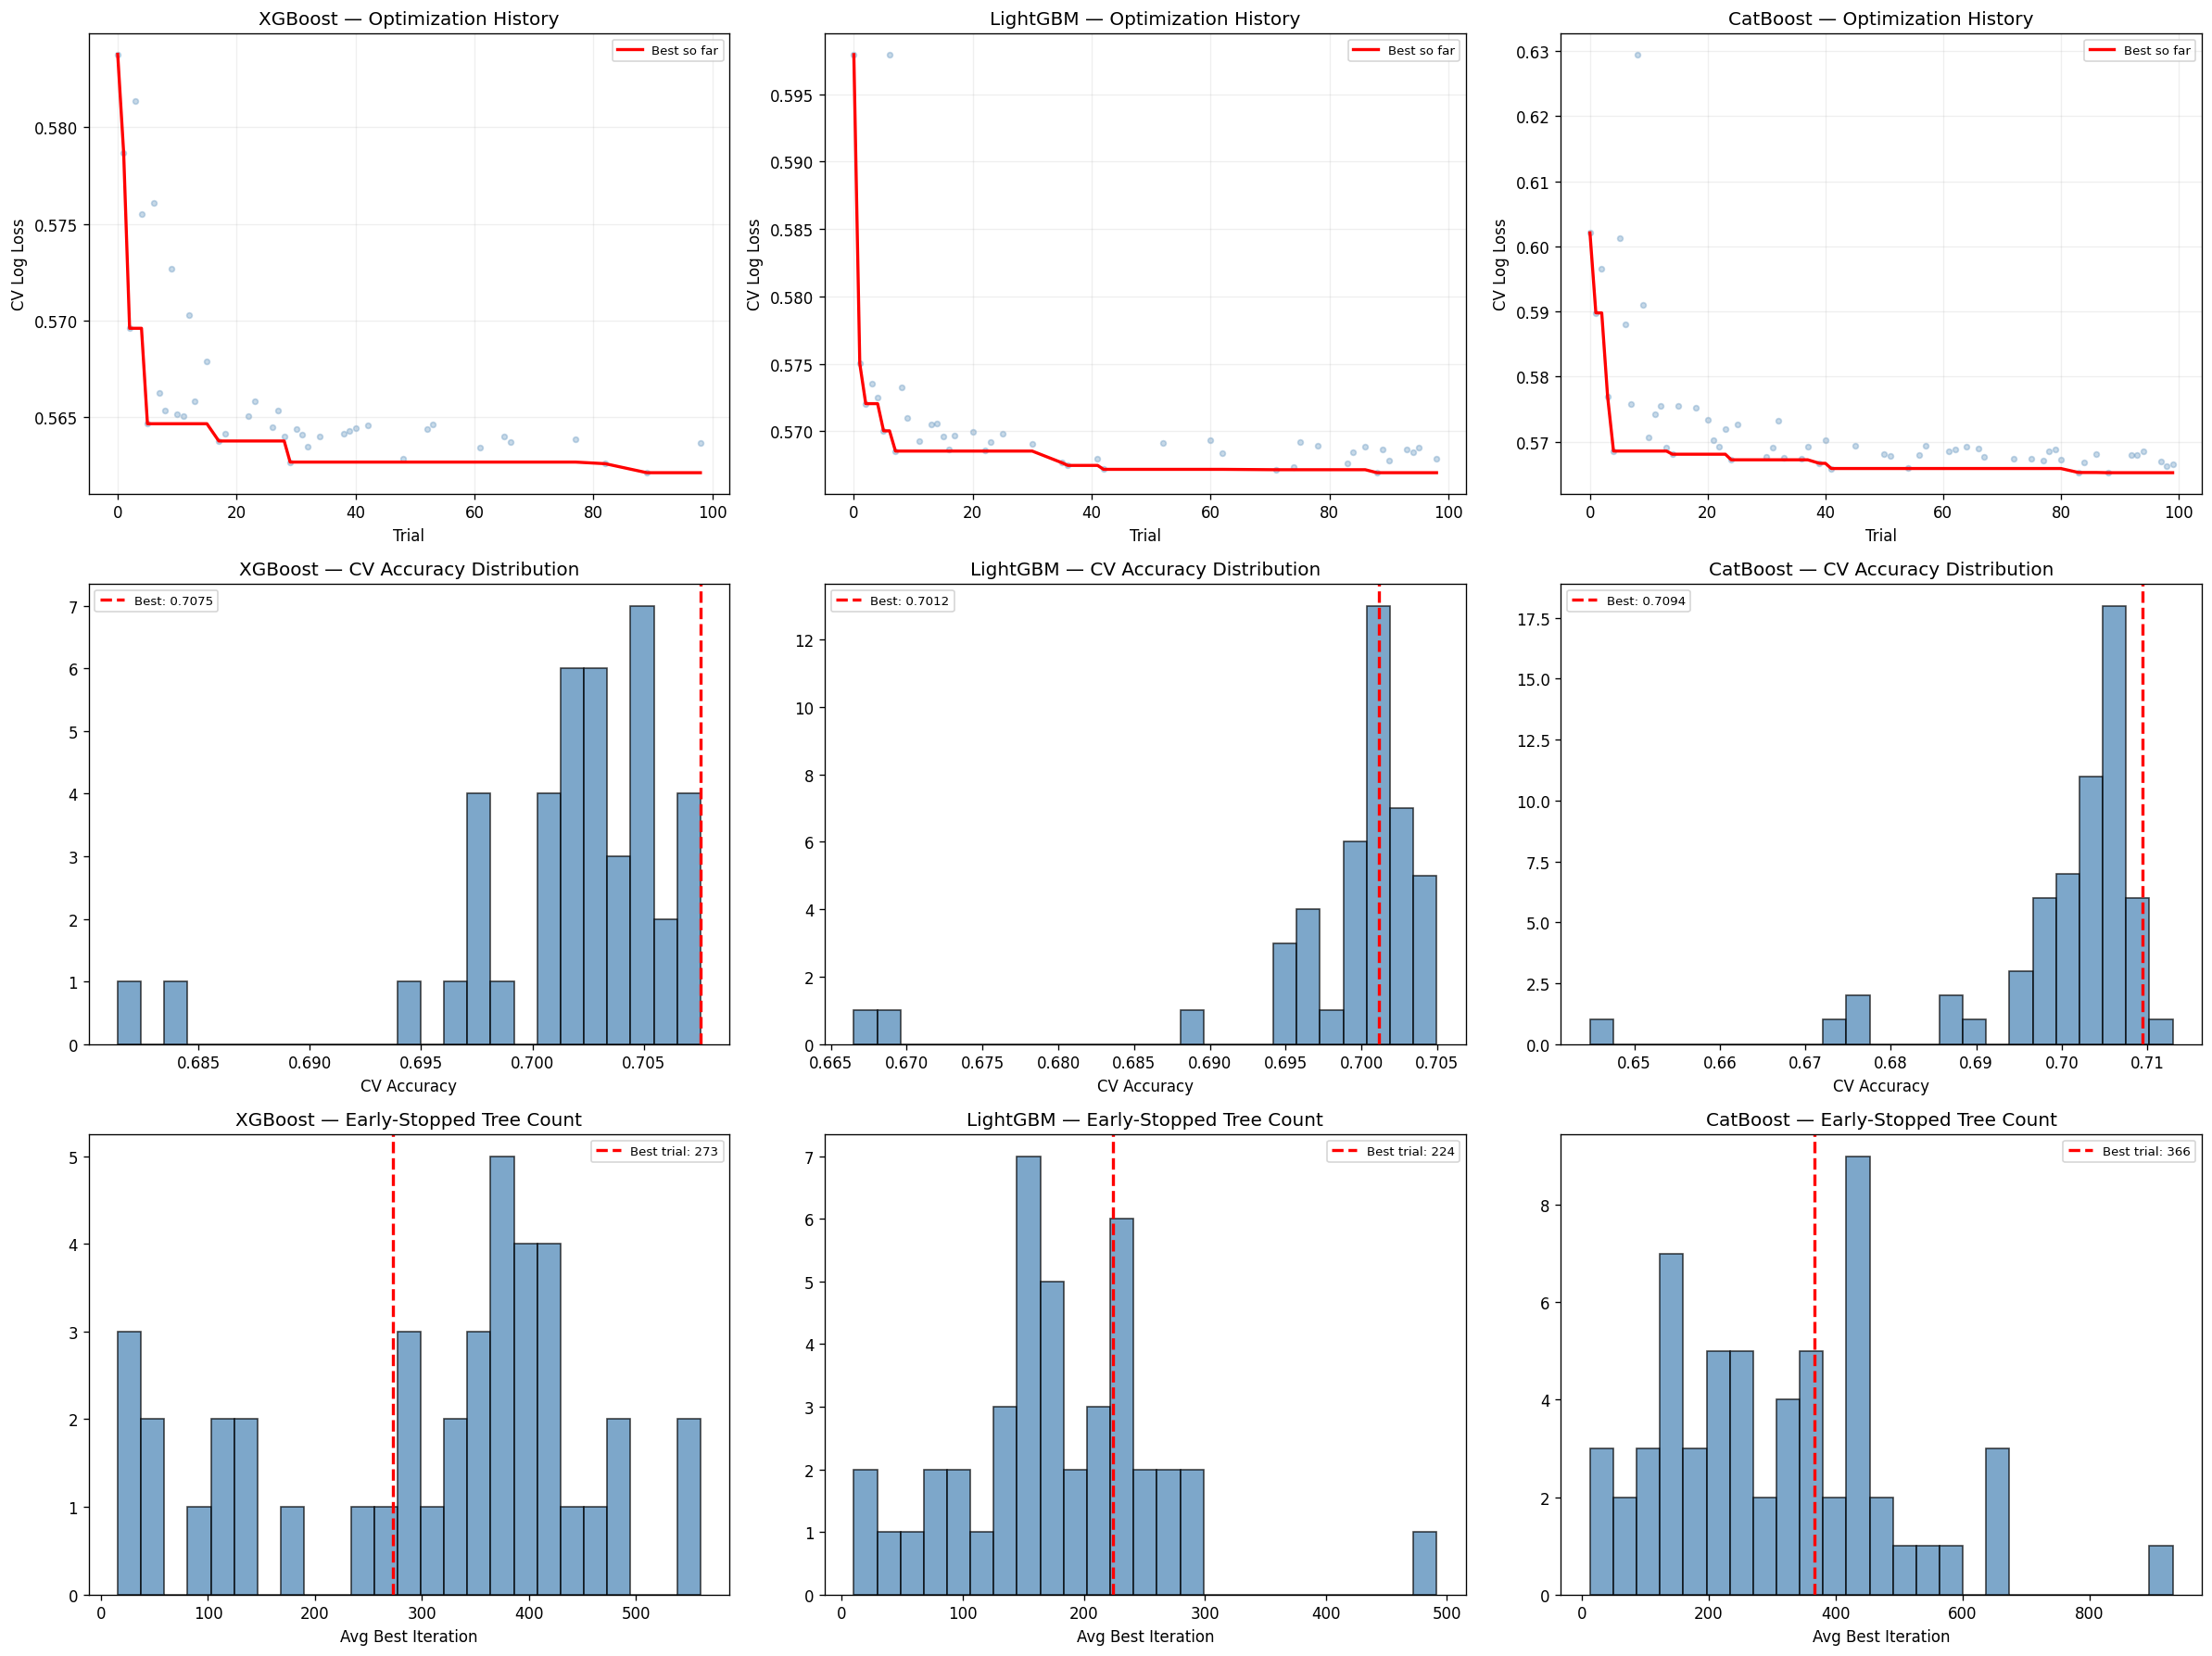

PARAMETER IMPORTANCE (fANOVA)

XGBoost:
  learning_rate             0.698 ███████████████████████████
  subsample                 0.108 ████
  colsample_bytree          0.053 ██
  max_depth                 0.049 █
  reg_alpha                 0.047 █
  min_child_weight          0.023 
  gamma                     0.014 
  reg_lambda                0.008 

LightGBM:
  learning_rate             0.611 ████████████████████████
  min_child_samples         0.104 ████
  colsample_bytree          0.103 ████
  subsample                 0.095 ███
  num_leaves                0.055 ██
  reg_alpha                 0.018 
  min_split_gain            0.010 
  reg_lambda                0.004 
  max_depth                 0.001 

CatBoost:
  l2_leaf_reg               0.339 █████████████
  subsample                 0.225 ████████
  learning_rate             0.195 ███████
  auto_class_weights        0.084 ███
  depth                     0.069 ██
  random_strength           0.065 ██
  min_data_in_leaf        

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

all_studies = [('XGBoost', xgb_study), ('LightGBM', lgb_study), ('CatBoost', cat_study)]

for col, (name, study) in enumerate(all_studies):
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    trial_nums = [t.number for t in completed]
    trial_vals = [t.value for t in completed]

    # Row 1: Optimization history
    ax = axes[0, col]
    best_so_far = pd.Series(trial_vals).cummin().values
    ax.scatter(trial_nums, trial_vals, alpha=0.3, s=12, c='steelblue')
    ax.plot(trial_nums, best_so_far, 'r-', lw=2, label='Best so far')
    ax.set_title(f'{name} — Optimization History')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV Log Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Row 2: CV Accuracy distribution
    ax = axes[1, col]
    accs = [t.user_attrs['cv_accuracy'] for t in completed]
    ax.hist(accs, bins=25, alpha=0.7, edgecolor='black', color='steelblue')
    best_acc = study.best_trial.user_attrs['cv_accuracy']
    ax.axvline(best_acc, color='red', ls='--', lw=2, label=f"Best: {best_acc:.4f}")
    ax.set_title(f'{name} — CV Accuracy Distribution')
    ax.set_xlabel('CV Accuracy')
    ax.legend(fontsize=8)

    # Row 3: Tree count distribution
    ax = axes[2, col]
    iters = [t.user_attrs['avg_best_iteration'] for t in completed]
    ax.hist(iters, bins=25, alpha=0.7, edgecolor='black', color='steelblue')
    best_iter = study.best_trial.user_attrs['avg_best_iteration']
    ax.axvline(best_iter, color='red', ls='--', lw=2, label=f"Best trial: {best_iter:.0f}")
    ax.set_title(f'{name} — Early-Stopped Tree Count')
    ax.set_xlabel('Avg Best Iteration')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA / 'optuna_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Parameter importance ──
print("PARAMETER IMPORTANCE (fANOVA)")
print("=" * 60)
for name, study in all_studies:
    try:
        importance = optuna.importance.get_param_importances(study)
        print(f"\n{name}:")
        for param, imp in sorted(importance.items(), key=lambda x: -x[1]):
            bar = '█' * int(imp * 40)
            print(f"  {param:<25s} {imp:.3f} {bar}")
    except Exception as e:
        print(f"\n{name}: Could not compute — {e}")

# ── Summary ──
total_time = xgb_time + lgb_time + cat_time
print(f"\n{'='*60}")
print(f"TUNING SUMMARY")
print(f"{'='*60}")
for name, study, t in [('XGBoost', xgb_study, xgb_time),
                        ('LightGBM', lgb_study, lgb_time),
                        ('CatBoost', cat_study, cat_time)]:
    comp = len([t2 for t2 in study.trials if t2.state == optuna.trial.TrialState.COMPLETE])
    prun = len([t2 for t2 in study.trials if t2.state == optuna.trial.TrialState.PRUNED])
    print(f"  {name:<12s} {comp} completed, {prun} pruned, {t/60:.1f} min, best LL={study.best_value:.4f}")
print(f"\n  Total time: {total_time/60:.1f} min ({total_time/3600:.1f} hr)")

## Tuned Feature Importance

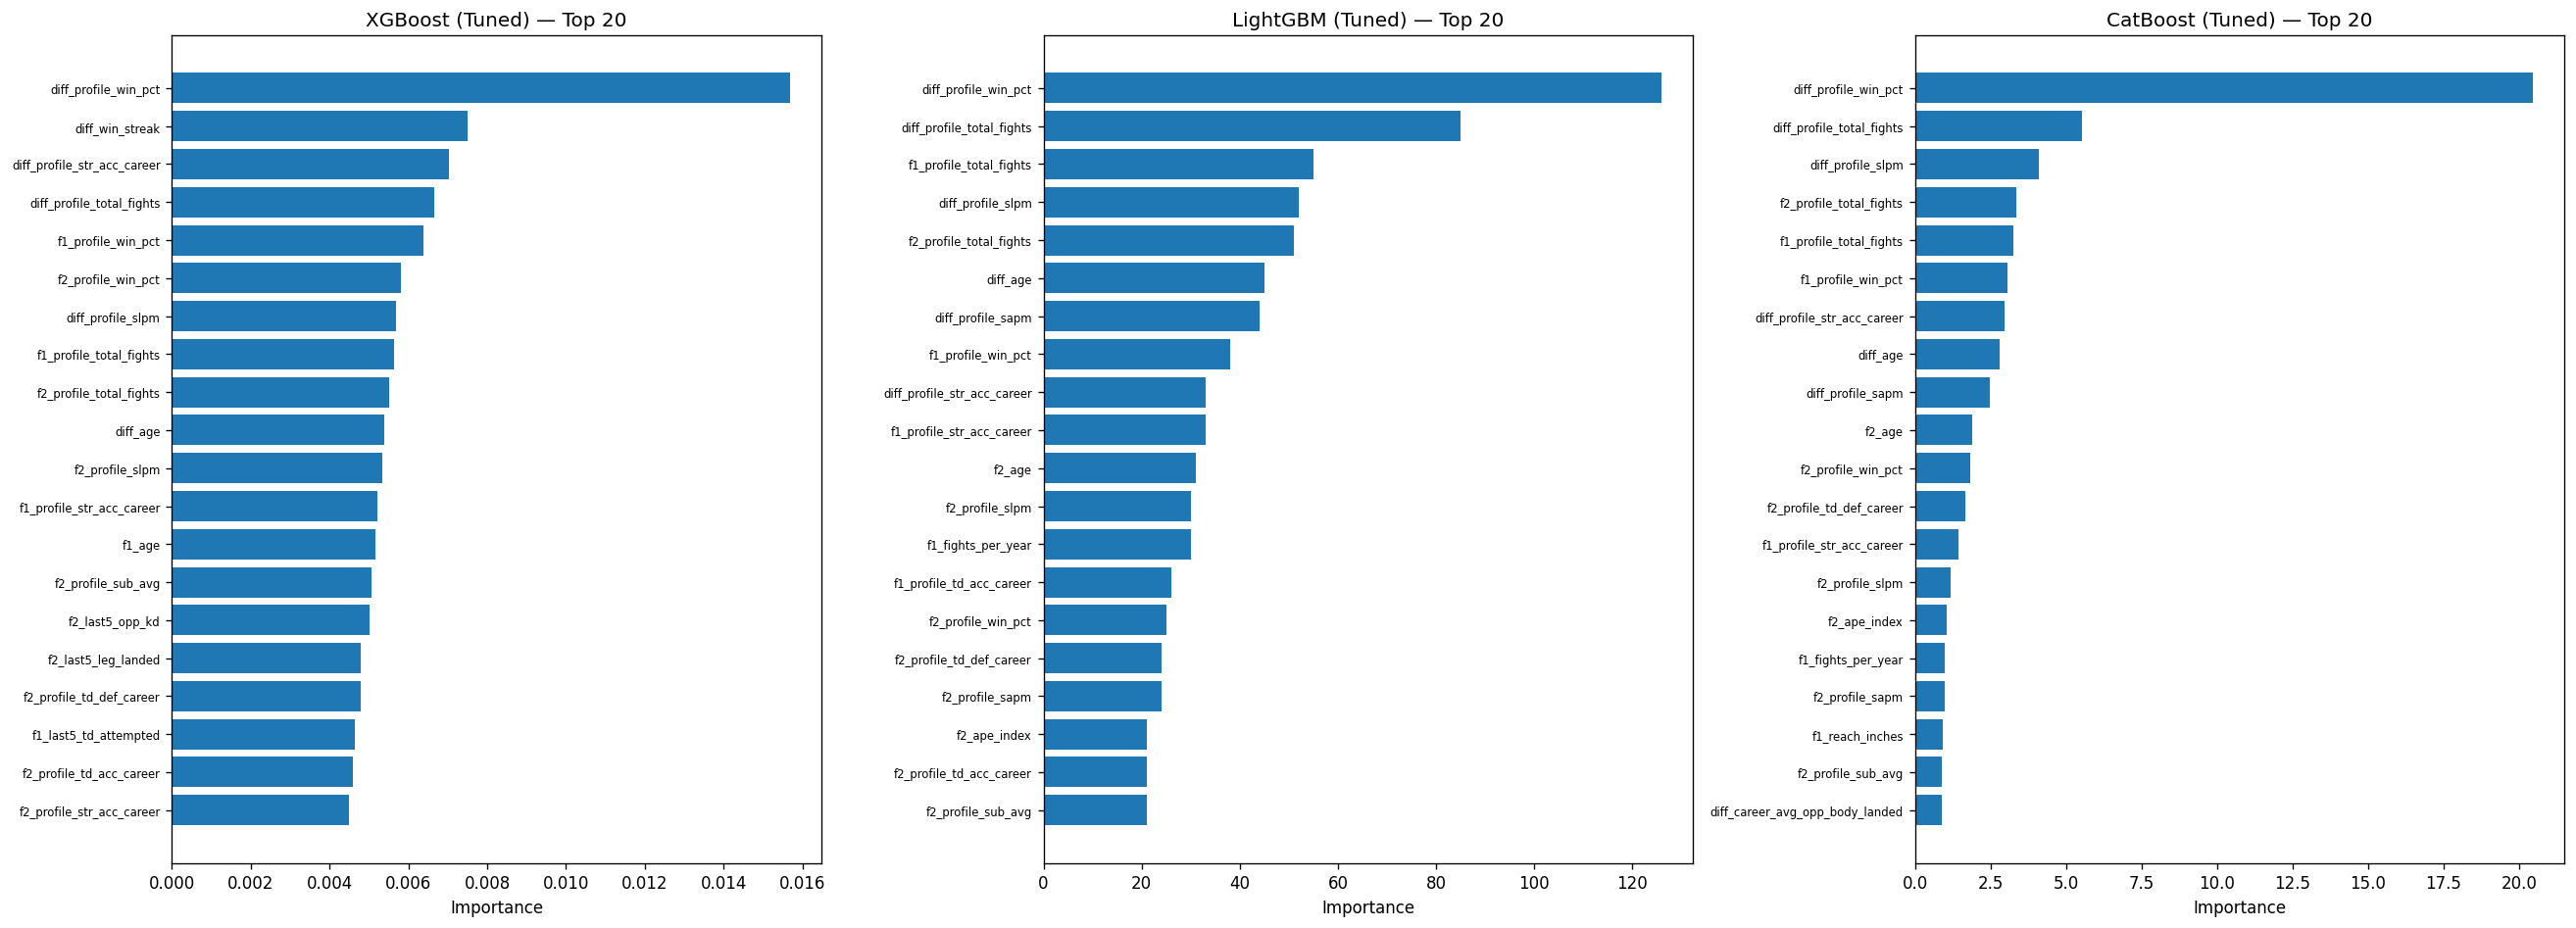

Consensus Top 20 (tuned models):
─────────────────────────────────────────────────────────────────
   1. diff_profile_win_pct                          [1/1/1]  PROFILE
   2. diff_profile_total_fights                     [4/2/2]  PROFILE
   3. diff_profile_slpm                             [7/4/3]  PROFILE
   4. f1_profile_total_fights                       [8/3/5]  PROFILE
   5. f2_profile_total_fights                       [9/5/4]  PROFILE
   6. f1_profile_win_pct                            [5/8/6]  PROFILE
   7. diff_profile_str_acc_career                   [3/10/7]  PROFILE
   8. diff_age                                      [10/6/8]  PHYSICAL
   9. f2_profile_win_pct                            [6/15/11]  PROFILE
  10. f1_profile_str_acc_career                     [12/10/13]  PROFILE
  11. f2_profile_slpm                               [11/12/14]  PROFILE
  12. diff_profile_sapm                             [24/7/9]  PROFILE
  13. f2_profile_td_def_career                      [17/16/12

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

importance_data = {}

for idx, name in enumerate(['XGBoost', 'LightGBM', 'CatBoost']):
    model = tuned[name]['model']
    imp = model.feature_importances_

    imp_df = pd.DataFrame({'feature': feature_cols, 'importance': imp})
    imp_df = imp_df.sort_values('importance', ascending=False)
    importance_data[name] = imp_df

    top20 = imp_df.head(20)
    ax = axes[idx]
    ax.barh(range(20), top20['importance'].values[::-1])
    ax.set_yticks(range(20))
    ax.set_yticklabels(top20['feature'].values[::-1], fontsize=7)
    ax.set_title(f'{name} (Tuned) — Top 20')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(DATA / 'tuned_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Consensus ──
rank_df = pd.DataFrame({'feature': feature_cols})
for name, imp_df in importance_data.items():
    temp = imp_df[['feature', 'importance']].copy()
    temp['rank'] = temp['importance'].rank(ascending=False)
    rank_df = rank_df.merge(temp[['feature', 'rank']], on='feature')
    rank_df = rank_df.rename(columns={'rank': f'rank_{name}'})

rank_cols = [c for c in rank_df.columns if c.startswith('rank_')]
rank_df['avg_rank'] = rank_df[rank_cols].mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')

print("Consensus Top 20 (tuned models):")
print("─" * 65)
for i, (_, row) in enumerate(rank_df.head(20).iterrows()):
    feat = row['feature']
    ranks = [f"{row[c]:.0f}" for c in rank_cols]
    ftype = ('PROFILE' if 'profile' in feat else
             'PHYSICAL' if any(x in feat for x in ['age', 'height', 'reach', 'ape', 'weight_lbs']) else
             'CAREER' if 'career' in feat else
             'LAST-3' if 'last3' in feat else
             'LAST-5' if 'last5' in feat else
             'ACTIVITY' if any(x in feat for x in ['streak', 'days_since', 'fights_per']) else
             'ENCODED' if any(x in feat for x in ['weight_class', 'stance', 'ortho', 'switch']) else
             'OTHER')
    print(f"  {i+1:>2}. {feat:<45s} [{'/'.join(ranks)}]  {ftype}")

## Calibration Analysis

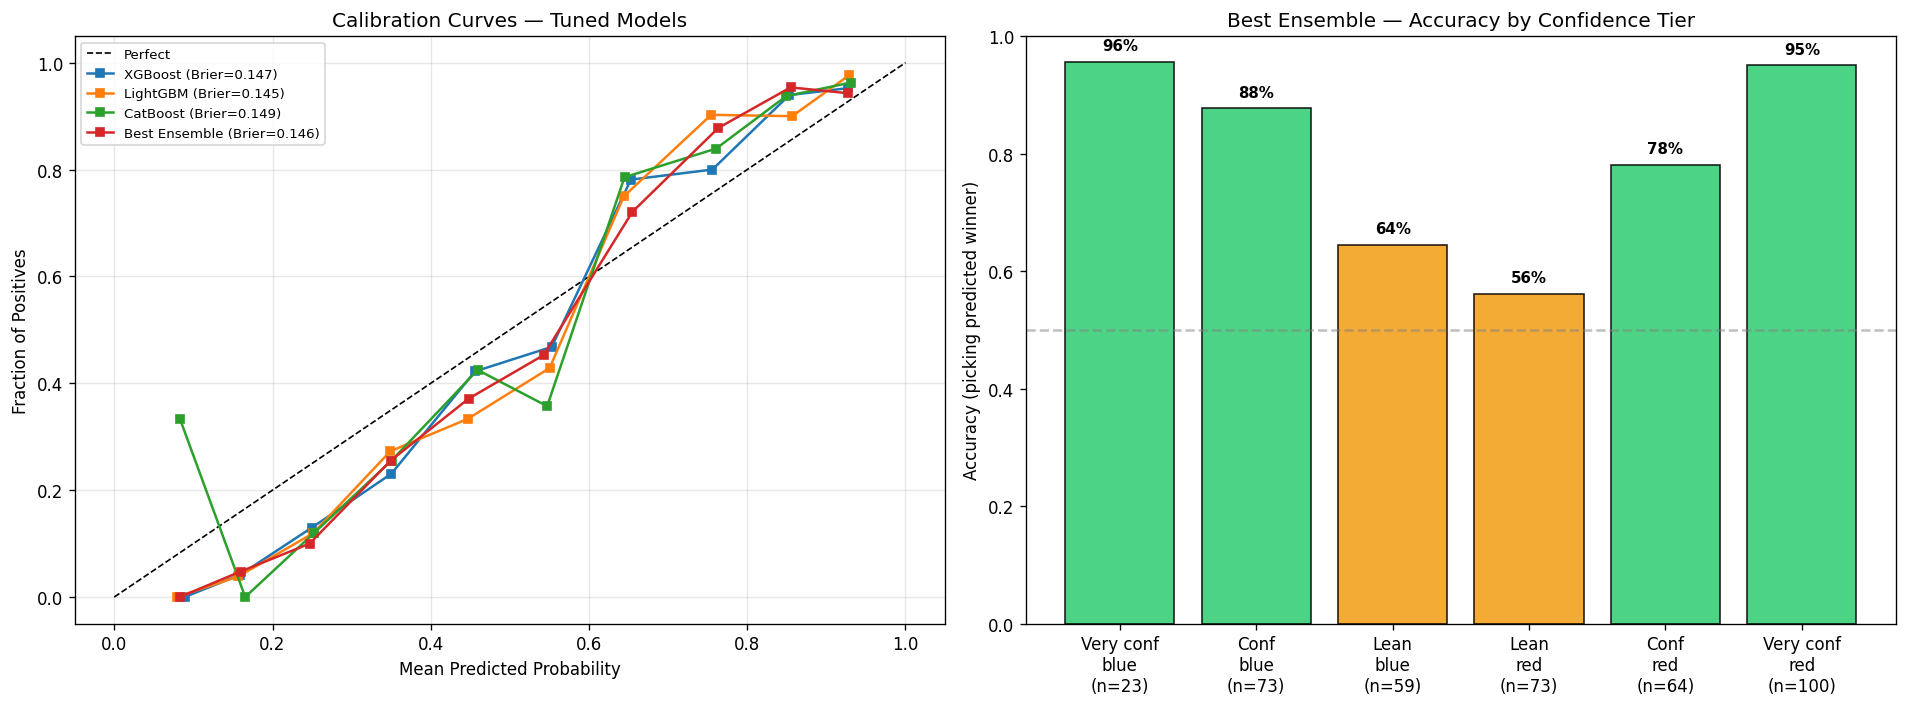

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Calibration curves ──
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')

models_to_plot = [
    ('XGBoost', tuned['XGBoost']['y_prob'], tuned['XGBoost']['test']['brier']),
    ('LightGBM', tuned['LightGBM']['y_prob'], tuned['LightGBM']['test']['brier']),
    ('CatBoost', tuned['CatBoost']['y_prob'], tuned['CatBoost']['test']['brier']),
    ('Best Ensemble', best_ens_prob, best_ens_metrics['brier']),
]

for name, prob, brier in models_to_plot:
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 's-', label=f"{name} (Brier={brier:.3f})", markersize=5)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves — Tuned Models')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Confidence bucket accuracy ──
ax = axes[1]

buckets = [
    (0.0,  0.20, 'Very conf\nblue'),
    (0.20, 0.35, 'Conf\nblue'),
    (0.35, 0.50, 'Lean\nblue'),
    (0.50, 0.65, 'Lean\nred'),
    (0.65, 0.80, 'Conf\nred'),
    (0.80, 1.01, 'Very conf\nred'),
]

labels, accs, counts = [], [], []
for lo, hi, label in buckets:
    mask = (best_ens_prob >= lo) & (best_ens_prob < hi)
    n = mask.sum()
    if n > 0:
        if lo < 0.5:
            acc = 1 - y_test[mask].mean()
        else:
            acc = y_test[mask].mean()
        labels.append(f"{label}\n(n={n})")
        accs.append(acc)
        counts.append(n)

colors = ['#e74c3c' if a < 0.55 else '#f39c12' if a < 0.65 else '#27ae60' if a < 0.75 else '#2ecc71'
          for a in accs]
bars = ax.bar(labels, accs, color=colors, edgecolor='black', alpha=0.85)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_ylabel('Accuracy (picking predicted winner)')
ax.set_title('Best Ensemble — Accuracy by Confidence Tier')
ax.set_ylim(0, 1.0)
for i, (a, n) in enumerate(zip(accs, counts)):
    ax.text(i, a + 0.02, f"{a:.0%}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(DATA / 'tuned_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

In [15]:
test_df = df.loc[test_mask].copy()
test_df['ens_prob'] = best_ens_prob
test_df['ens_pred'] = best_ens_pred
test_df['correct'] = (test_df['ens_pred'] == test_df['f1_win']).astype(int)
test_df['confidence'] = (test_df['ens_prob'] - 0.5).abs()

# ── Confident wrong ──
print("CONFIDENT WRONG PREDICTIONS (>80% confidence)")
print("=" * 100)

conf_wrong = test_df[
    (test_df['correct'] == 0) &
    ((test_df['ens_prob'] > 0.80) | (test_df['ens_prob'] < 0.20))
].sort_values('confidence', ascending=False)

print(f"Total: {len(conf_wrong)} fights")
for _, row in conf_wrong.head(15).iterrows():
    prob = row['ens_prob']
    favored = row['fighter_1'] if prob >= 0.5 else row['fighter_2']
    actual  = row['fighter_1'] if row['f1_win'] == 1 else row['fighter_2']
    conf = max(prob, 1 - prob)
    print(f"  {row['event_date'].strftime('%Y-%m-%d')} | {row['fighter_1']:<22s} vs {row['fighter_2']:<22s} | "
          f"Pick: {favored:<22s} ({conf:.0%}) | Won: {actual}")

# ── By weight class ──
print(f"\n{'='*80}")
print("ACCURACY BY WEIGHT CLASS")
print(f"{'='*80}")
wc = test_df.groupby('weight_class').agg(
    n=('correct', 'count'),
    acc=('correct', 'mean'),
    base=('f1_win', 'mean'),
).sort_values('acc', ascending=False)
wc['lift'] = wc['acc'] - wc['base']

for wc_name, row in wc.iterrows():
    bar = '█' * int(row['acc'] * 30)
    print(f"  {wc_name:<28s} n={row['n']:>3.0f}  acc={row['acc']:.3f}  base={row['base']:.3f}  "
          f"lift={row['lift']:+.3f}  {bar}")

# ── By finish type ──
print(f"\n{'='*80}")
print("ACCURACY BY FINISH TYPE")
print(f"{'='*80}")
ft = test_df.groupby('finish_type').agg(
    n=('correct', 'count'),
    acc=('correct', 'mean'),
).sort_values('n', ascending=False)
for ft_name, row in ft.iterrows():
    print(f"  {ft_name:<12s} n={row['n']:>3.0f}  acc={row['acc']:.3f}")

# ── Monthly trend ──
print(f"\n{'='*80}")
print("ACCURACY OVER TIME")
print(f"{'='*80}")
test_df['month'] = test_df['event_date'].dt.to_period('M')
monthly = test_df.groupby('month').agg(n=('correct', 'count'), acc=('correct', 'mean'))
for period, row in monthly.iterrows():
    bar = '█' * int(row['acc'] * 30)
    print(f"  {period}  n={row['n']:>3.0f}  acc={row['acc']:.3f}  {bar}")

CONFIDENT WRONG PREDICTIONS (>80% confidence)
Total: 6 fights
  2026-01-24 | Arnold Allen           vs Jean Silva             | Pick: Arnold Allen           (92%) | Won: Jean Silva
  2026-04-04 | Azamat Bekoev          vs Tresean Gore           | Pick: Azamat Bekoev          (91%) | Won: Tresean Gore
  2026-04-11 | Azamat Murzakanov      vs Paulo Costa            | Pick: Azamat Murzakanov      (85%) | Won: Paulo Costa
  2025-10-18 | Bruno Silva            vs HyunSung Park          | Pick: HyunSung Park          (84%) | Won: Bruno Silva
  2026-02-07 | Jailton Almeida        vs Rizvan Kuniev          | Pick: Jailton Almeida        (84%) | Won: Rizvan Kuniev
  2025-10-04 | Magomed Ankalaev       vs Alex Pereira           | Pick: Magomed Ankalaev       (83%) | Won: Alex Pereira

ACCURACY BY WEIGHT CLASS
  Women's Bantamweight         n= 15  acc=0.933  base=0.667  lift=+0.267  ████████████████████████████
  Women's Flyweight            n= 15  acc=0.933  base=0.867  lift=+0.067  ████████████

## Confusion Matrices

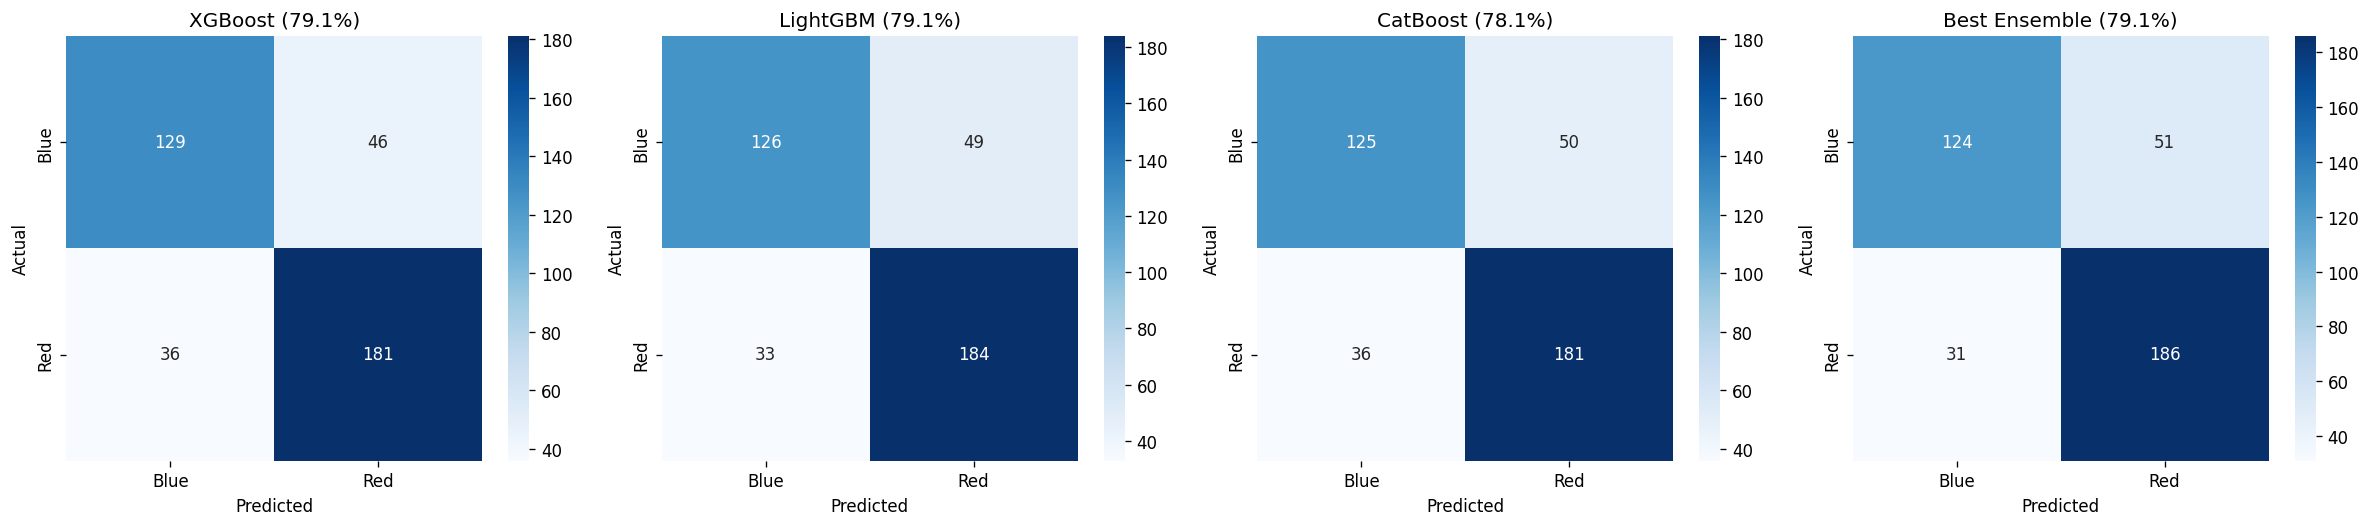

Best Ensemble Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.80      0.71      0.75       175
    Red wins       0.78      0.86      0.82       217

    accuracy                           0.79       392
   macro avg       0.79      0.78      0.79       392
weighted avg       0.79      0.79      0.79       392



In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

plot_models = [
    ('XGBoost', tuned['XGBoost']['y_pred']),
    ('LightGBM', tuned['LightGBM']['y_pred']),
    ('CatBoost', tuned['CatBoost']['y_pred']),
    ('Best Ensemble', best_ens_pred),
]

for idx, (name, y_pred_m) in enumerate(plot_models):
    cm = confusion_matrix(y_test, y_pred_m)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Blue', 'Red'], yticklabels=['Blue', 'Red'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    acc = accuracy_score(y_test, y_pred_m)
    ax.set_title(f'{name} ({acc:.1%})')

plt.tight_layout()
plt.savefig(DATA / 'tuned_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("Best Ensemble Classification Report:")
print(classification_report(y_test, best_ens_pred, target_names=['Blue wins', 'Red wins']))

## Phase 2: Production Models

Retrain best hyperparameters on **ALL data** (2015–2026). These models are for
predicting future fights. No test evaluation possible — we trust CV results.

In [17]:
X_all = df[feature_cols]
y_all = df[target]
print(f"Training production models on ALL {len(X_all):,} fights\n")

prod_models = {}

# XGBoost
xgb_iter = max(int(xgb_study.best_trial.user_attrs['avg_best_iteration'] * 1.1), 100)
xgb_prod = XGBClassifier(
    **xgb_study.best_params,
    n_estimators=xgb_iter, eval_metric='logloss',
    random_state=42, n_jobs=-1, verbosity=0,
)
xgb_prod.fit(X_all, y_all)
prod_models['XGBoost'] = xgb_prod
print(f"  XGBoost:  {xgb_iter} trees")

# LightGBM
lgb_iter = max(int(lgb_study.best_trial.user_attrs['avg_best_iteration'] * 1.1), 100)
lgb_prod = LGBMClassifier(
    **lgb_study.best_params,
    n_estimators=lgb_iter, metric='binary_logloss',
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_prod.fit(X_all, y_all)
prod_models['LightGBM'] = lgb_prod
print(f"  LightGBM: {lgb_iter} trees")

# CatBoost
cat_iter = max(int(cat_study.best_trial.user_attrs['avg_best_iteration'] * 1.1), 100)
cat_prod = CatBoostClassifier(
    **cat_study.best_params,
    iterations=cat_iter, eval_metric='Logloss',
    random_seed=42, verbose=0,
)
cat_prod.fit(X_all, y_all)
prod_models['CatBoost'] = cat_prod
print(f"  CatBoost: {cat_iter} trees")

print(f"\n✅ Production models trained on {len(X_all):,} fights")

Training production models on ALL 5,485 fights

  XGBoost:  300 trees
  LightGBM: 246 trees
  CatBoost: 402 trees

✅ Production models trained on 5,485 fights


## Save Models, Params & Predictions

In [18]:
# ── Save tuned models (Phase 1 — evaluated on test) ──
tuned['XGBoost']['model'].save_model(str(MODEL_DIR / 'xgb_tuned.json'))
tuned['LightGBM']['model'].booster_.save_model(str(MODEL_DIR / 'lgb_tuned.txt'))
tuned['CatBoost']['model'].save_model(str(MODEL_DIR / 'cat_tuned.cbm'))

# ── Save production models (Phase 2 — trained on all data) ──
prod_models['XGBoost'].save_model(str(MODEL_DIR / 'xgb_prod.json'))
prod_models['LightGBM'].booster_.save_model(str(MODEL_DIR / 'lgb_prod.txt'))
prod_models['CatBoost'].save_model(str(MODEL_DIR / 'cat_prod.cbm'))

# ── Save best params ──
best_params_all = {}
for name, study in [('XGBoost', xgb_study), ('LightGBM', lgb_study), ('CatBoost', cat_study)]:
    best_params_all[name] = {
        'params': {k: v for k, v in study.best_params.items()},
        'best_cv_ll': study.best_value,
        'best_cv_acc': study.best_trial.user_attrs['cv_accuracy'],
        'avg_best_iteration': study.best_trial.user_attrs['avg_best_iteration'],
        'test_metrics': tuned[name]['test'],
    }
best_params_all['best_ensemble_weights'] = {k: round(v, 4) for k, v in best_weights.items()}
best_params_all['best_ensemble_scheme'] = best_scheme

with open(DATA / 'best_params.json', 'w') as f:
    json.dump(best_params_all, f, indent=2, default=str)

# ── Save predictions ──
pred_df = df.loc[test_mask, ['event_name', 'event_date', 'fighter_1', 'fighter_2',
                              'weight_class', 'f1_win', 'finish_type']].copy()
pred_df['xgb_prob'] = tuned['XGBoost']['y_prob']
pred_df['lgb_prob'] = tuned['LightGBM']['y_prob']
pred_df['cat_prob'] = tuned['CatBoost']['y_prob']
pred_df['ens_prob'] = best_ens_prob
pred_df['ens_pred'] = best_ens_pred
pred_df['correct']  = (best_ens_pred == y_test.values).astype(int)

# Add confidence tier
pred_df['confidence'] = (pred_df['ens_prob'] - 0.5).abs()
unanimous = (
    (tuned['XGBoost']['y_pred'] == tuned['LightGBM']['y_pred']) &
    (tuned['LightGBM']['y_pred'] == tuned['CatBoost']['y_pred'])
)
pred_df['unanimous'] = unanimous

def get_tier(row):
    if not row['unanimous']:
        return 'NO_CONF'
    if row['confidence'] >= 0.30:
        return 'VERY_HIGH'
    elif row['confidence'] >= 0.20:
        return 'HIGH'
    elif row['confidence'] >= 0.10:
        return 'MEDIUM'
    return 'LOW'

pred_df['tier'] = pred_df.apply(get_tier, axis=1)
pred_df.to_csv(DATA / 'test_predictions_tuned.csv', index=False)

# ── Save feature list ──
with open(DATA / 'feature_list.txt', 'w') as f:
    for feat in feature_cols:
        f.write(feat + '\n')

print("Saved:")
print(f"  Tuned models:      {MODEL_DIR}/xgb_tuned.json, lgb_tuned.txt, cat_tuned.cbm")
print(f"  Production models: {MODEL_DIR}/xgb_prod.json, lgb_prod.txt, cat_prod.cbm")
print(f"  Best params:       {DATA}/best_params.json")
print(f"  Predictions:       {DATA}/test_predictions_tuned.csv ({len(pred_df)} rows)")
print(f"  Feature list:      {DATA}/feature_list.txt ({len(feature_cols)} features)")

# ── Final summary ──
print("\n" + "=" * 90)
print("NOTEBOOK 06 — FINAL SUMMARY")
print("=" * 90)
print(f"Split: train < {SPLIT_DATE} ({len(X_train):,}) | test >= {SPLIT_DATE} ({len(X_test):,})")
print(f"Features: {len(feature_cols)} | Baseline: {baseline_acc:.3f}")
print(f"Optuna: {N_TRIALS} trials/model, {N_SPLITS}-fold CV, early_stop={EARLY_STOP_ROUNDS}, MedianPruner")
total_time = xgb_time + lgb_time + cat_time
print(f"Total tuning time: {total_time/60:.1f} min ({total_time/3600:.1f} hr)")

print(f"\n{'Model':<12} {'NB05':>8} {'Tuned':>8} {'Delta':>8} {'CV LL':>8} {'Test LL':>8} {'AUC':>8} {'Brier':>8}")
print("─" * 90)
for name in ['XGBoost', 'LightGBM', 'CatBoost']:
    nb05 = nb05_results[name]
    t = tuned[name]['test']
    study = {'XGBoost': xgb_study, 'LightGBM': lgb_study, 'CatBoost': cat_study}[name]
    d = t['acc'] - nb05['acc']
    print(f"{name:<12} {nb05['acc']:>8.3f} {t['acc']:>8.3f} {d:>+8.3f} "
          f"{study.best_value:>8.4f} {t['ll']:>8.3f} {t['auc']:>8.3f} {t['brier']:>8.3f}")

# Ensemble row
nb05_ens = nb05_results['Ensemble']
d_ens = best_ens_metrics['acc'] - nb05_ens['acc']
print(f"{'Ensemble':<12} {nb05_ens['acc']:>8.3f} {best_ens_metrics['acc']:>8.3f} {d_ens:>+8.3f} "
      f"{'—':>8} {best_ens_metrics['ll']:>8.3f} {best_ens_metrics['auc']:>8.3f} {best_ens_metrics['brier']:>8.3f}")

print(f"\nBest ensemble: {best_scheme}")
print(f"Production models trained on all {len(X_all):,} fights — ready for inference.")
print("=" * 90)

Saved:
  Tuned models:      ../models/xgb_tuned.json, lgb_tuned.txt, cat_tuned.cbm
  Production models: ../models/xgb_prod.json, lgb_prod.txt, cat_prod.cbm
  Best params:       data/best_params.json
  Predictions:       data/test_predictions_tuned.csv (392 rows)
  Feature list:      data/feature_list.txt (310 features)

NOTEBOOK 06 — FINAL SUMMARY
Split: train < 2025-07-01 (5,093) | test >= 2025-07-01 (392)
Features: 310 | Baseline: 0.554
Optuna: 100 trials/model, 5-fold CV, early_stop=20, MedianPruner
Total tuning time: 24.7 min (0.4 hr)

Model            NB05    Tuned    Delta    CV LL  Test LL      AUC    Brier
──────────────────────────────────────────────────────────────────────────────────────────
XGBoost         0.768    0.791   +0.023   0.5621    0.459    0.874    0.147
LightGBM        0.781    0.791   +0.010   0.5669    0.453    0.885    0.145
CatBoost        0.786    0.781   -0.005   0.5652    0.465    0.878    0.149
Ensemble        0.773    0.791   +0.018        —    0.458  